# Exercises

There are three exercises in this notebook:

1. Use the cross-validation method to test the linear regression with different $\alpha$ values, at least three.
2. Implement a SGD method that will train the Lasso regression for 10 epochs.
3. Extend the Fisher's classifier to work with two features. Use the class as the $y$.

## 1. Cross-validation linear regression

You need to change the variable ``alpha`` to be a list of alphas. Next do a loop and finally compare the results.

In [40]:
import numpy as np

x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = np.asmatrix(np.c_[np.ones((15,1)),x])

I = np.identity(2)
alphas = [0.5, 1, 5]
results = []

for alpha in alphas:
    w = np.linalg.inv(x.T*x + alpha * I)*x.T*y
    w=w.ravel()

    y_pred = x * w.reshape(-1,1)
    mse = np.mean(np.square(y_pred - y))
    results.append((alpha, w, mse))

for alpha, w, mse in results:
    print(f"alpha={alpha}, weights={w}, MSE={mse}")


alpha=0.5, weights=[[-36.97522016   0.80324169]], MSE=549.7710602647363
alpha=1, weights=[[-20.59044706   0.71048616]], MSE=592.4636104956187
alpha=5, weights=[[-4.52802264  0.61955099]], MSE=638.7792044591035


## 2. Implement based on the Ridge regression example, the Lasso regression.

Please implement the SGD method and compare the results with the sklearn Lasso regression results. 

In [42]:
import numpy as np
from sklearn.linear_model import Lasso

def sgd(x, y, alpha=0.1, lr=0.00001, epochs=10):
    w = np.zeros((2, 1))

    for epoch in range(epochs):
        for i in range(len(x)):
            xi = x[i]
            yi = y[i, 0]

            error = (xi @ w)[0, 0] - yi

            w[0, 0] -= lr * error * xi[0, 0]

            w[1, 0] -= lr * (error * xi[0, 1] + alpha * np.sign(w[1, 0]))

    return w

In [43]:
x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x2 = np.asmatrix(np.c_[np.ones((15,1)),x])

alpha = 0.1

w_sgd = sgd(x2, y, alpha=0.1, lr=0.000001, epochs=10)
print("SGD Lasso:", w_sgd.ravel())

model = Lasso(alpha=0.1, max_iter=10000)
model.fit(x, y.ravel())

print("sklearn intercept:", model.intercept_)
print("sklearn coef:", model.coef_)


SGD Lasso: [0.00307599 0.58719138]
sklearn intercept: -180.85790859980537
sklearn coef: [1.61776499]


The results from SGD differ significantly from sklearn's Lasso because SGD was run for only 10 epochs, which is not enough for convergence. Sklearn uses a more advanced optimization method (coordinate descent), which converges faster. With more epochs, SGD would produce results closer to sklearn.

## 3. Extend the Fisher's classifier

Write numpy code that performs Fisher classification using all the features of Iris data. Choose species nr 1 and 2 as two classes. Plot original data and their projection. Using obtained model classify the flower with the folowing features: [6.45, 2.85, 4.25, 1.25].

Predicted class: 1
Species: versicolor


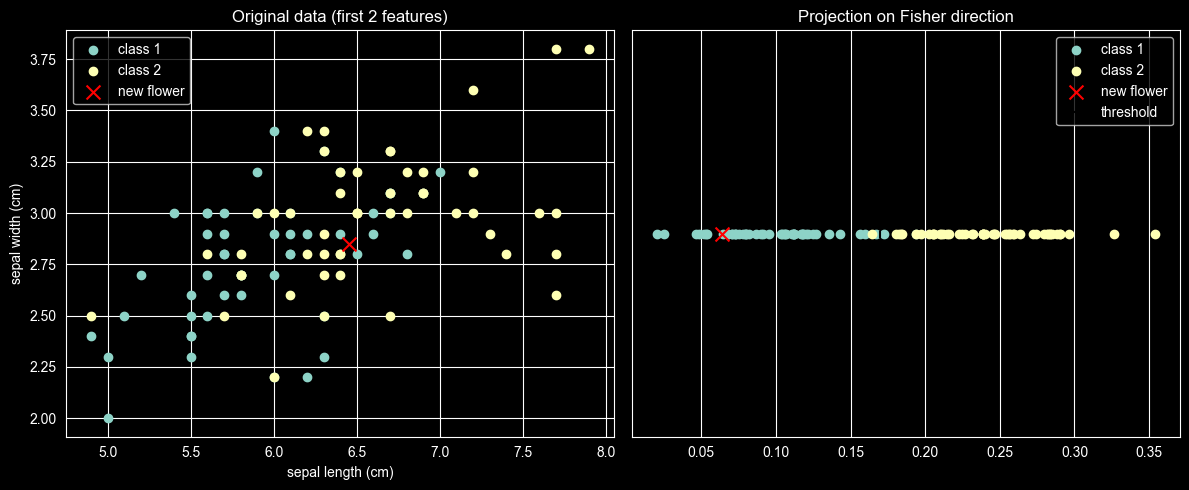

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

mask = np.isin(y, [1, 2])
X = X[mask]
y = y[mask]

X1 = X[y == 1]
X2 = X[y == 2]

m1 = X1.mean(axis=0)
m2 = X2.mean(axis=0)

Sw = (X1 - m1).T @ (X1 - m1) + (X2 - m2).T @ (X2 - m2)

w = np.linalg.solve(Sw, m2 - m1)

p1 = X1 @ w
p2 = X2 @ w

t = (p1.mean() + p2.mean()) / 2

x = np.array([6.45, 2.85, 4.25, 1.25])
px = x @ w

pred = 2 if px > t else 1
print("Predicted class:", pred)
print("Species:", iris.target_names[pred])

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

#2 features
ax[0].scatter(X1[:, 0], X1[:, 1], label='class 1')
ax[0].scatter(X2[:, 0], X2[:, 1], label='class 2')
ax[0].scatter(x[0], x[1], c='red', marker='x', s=100, label='new flower')
ax[0].set_xlabel(iris.feature_names[0])
ax[0].set_ylabel(iris.feature_names[1])
ax[0].set_title("Original data (first 2 features)")
ax[0].legend()


ax[1].scatter(p1, np.zeros_like(p1), label='class 1')
ax[1].scatter(p2, np.zeros_like(p2), label='class 2')
ax[1].scatter(px, 0, c='red', marker='x', s=100, label='new flower')
ax[1].axvline(t, linestyle='--', color='black', label='threshold')
ax[1].set_title("Projection on Fisher direction")
ax[1].set_yticks([])
ax[1].legend()

plt.tight_layout()
plt.show()